### 1. Generate an Encryption Key

First, we'll generate a symmetric encryption key using `cryptography`. This key should be securely stored and managed in a real application, not hardcoded or generated on the fly for each operation.

In [ ]:
from cryptography.fernet import Fernet
import json

# Generate a key (in a real app, this would be generated once and stored securely)
key = Fernet.generate_key()
fernet = Fernet(key)

print(f"Encryption Key (for demonstration): {key.decode()}")
print("Store this key securely! Without it, you cannot decrypt the data.")


Encryption Key (for demonstration): K7H4c6k9go2gH7W5Zyo2PPWK7Srln3cPN79exCssW48=
Store this key securely! Without it, you cannot decrypt the data.


### 2. Simulate Data Reception, Encryption, and Storage

Here, we'll simulate a WebSocket handler receiving data, encrypting it, and then 'inserting' it into a mock database (a Python list in this case). We'll assume incoming data is JSON.

In [ ]:
# Mock database to store encrypted payloads
mock_database = []

def encrypt_and_store_payload(raw_data: dict):
    """Simulates receiving data, encrypting it, and storing it."""
    print(f"\nReceived raw data: {raw_data}")

    # Convert dictionary to JSON string, then to bytes for encryption
    data_bytes = json.dumps(raw_data).encode('utf-8')

    # Encrypt the payload
    encrypted_payload = fernet.encrypt(data_bytes)

    # Simulate database insertion
    mock_database.append(encrypted_payload)
    print(f"Encrypted payload stored in mock_database: {encrypted_payload[:50]}...") # Show first 50 bytes

# --- Simulate receiving some real-time data ---
heart_rate_data_1 = {"user_id": "user_123", "timestamp": "2023-10-27T10:00:00Z", "metric": "heart_rate", "value": 72}
steps_data_1 = {"user_id": "user_456", "timestamp": "2023-10-27T10:00:15Z", "metric": "steps", "value": 120}
heart_rate_data_2 = {"user_id": "user_123", "timestamp": "2023-10-27T10:00:30Z", "metric": "heart_rate", "value": 75}

encrypt_and_store_payload(heart_rate_data_1)
encrypt_and_store_payload(steps_data_1)
encrypt_and_store_payload(heart_rate_data_2)

print(f"\nTotal encrypted payloads in mock_database: {len(mock_database)}")



Received raw data: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:00Z', 'metric': 'heart_rate', 'value': 72}
Encrypted payload stored in mock_database: b'gAAAAABpxNkXin4rJ4mf83J_RTAIj9joDoeAnp8lMVkkrV86OZ'...

Received raw data: {'user_id': 'user_456', 'timestamp': '2023-10-27T10:00:15Z', 'metric': 'steps', 'value': 120}
Encrypted payload stored in mock_database: b'gAAAAABpxNkXiscfERTcJvcv2Co1vO1uqpCHW8csiqDdMNwG3F'...

Received raw data: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:30Z', 'metric': 'heart_rate', 'value': 75}
Encrypted payload stored in mock_database: b'gAAAAABpxNkXEDPQuHT8jRjmbSRM9pbU39Ri23RuSV7aUdhdwH'...

Total encrypted payloads in mock_database: 3


### 3. Retrieve and Decrypt Data

To demonstrate successful encryption, we'll now retrieve a payload from our mock database and decrypt it to verify its original content.

In [ ]:
def retrieve_and_decrypt_payload(encrypted_payload: bytes) -> dict:
    """Retrieves an encrypted payload and decrypts it."""
    print(f"\nRetrieving encrypted payload: {encrypted_payload[:50]}...")

    # Decrypt the payload
    decrypted_bytes = fernet.decrypt(encrypted_payload)

    # Convert bytes back to JSON string, then to dictionary
    decrypted_data = json.loads(decrypted_bytes.decode('utf-8'))

    print(f"Decrypted data: {decrypted_data}")
    return decrypted_data

# Decrypt the first stored item
if mock_database:
    first_encrypted_item = mock_database[0]
    original_data = retrieve_and_decrypt_payload(first_encrypted_item)
    print(f"Verification: Original data matches stored data: {original_data == heart_rate_data_1}")

# Decrypt the second stored item
if len(mock_database) > 1:
    second_encrypted_item = mock_database[1]
    original_data_2 = retrieve_and_decrypt_payload(second_encrypted_item)
    print(f"Verification: Original data matches stored data: {original_data_2 == steps_data_1}")



Retrieving encrypted payload: b'gAAAAABpxNkXin4rJ4mf83J_RTAIj9joDoeAnp8lMVkkrV86OZ'...
Decrypted data: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:00Z', 'metric': 'heart_rate', 'value': 72}
Verification: Original data matches stored data: True

Retrieving encrypted payload: b'gAAAAABpxNkXiscfERTcJvcv2Co1vO1uqpCHW8csiqDdMNwG3F'...
Decrypted data: {'user_id': 'user_456', 'timestamp': '2023-10-27T10:00:15Z', 'metric': 'steps', 'value': 120}
Verification: Original data matches stored data: True


### Conceptual WebSocket Server Handler

Below is an example of how a WebSocket message handler *would* look using the `websockets` library. This code block is for conceptual understanding and won't run directly as a persistent server in Colab without specific setup.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Decrypt all items from the mock_database
decrypted_data_list = []
for encrypted_item in mock_database:
    decrypted_data_list.append(retrieve_and_decrypt_payload(encrypted_item))

# Convert to DataFrame
df_metrics = pd.DataFrame(decrypted_data_list)

# Convert timestamp to datetime objects for plotting
df_metrics['timestamp'] = pd.to_datetime(df_metrics['timestamp'])

# Sort by timestamp to ensure correct plotting order
df_metrics = df_metrics.sort_values(by='timestamp')

print("Decrypted data DataFrame:")
display(df_metrics.head())



Retrieving encrypted payload: b'gAAAAABpxNkXin4rJ4mf83J_RTAIj9joDoeAnp8lMVkkrV86OZ'...
Decrypted data: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:00Z', 'metric': 'heart_rate', 'value': 72}

Retrieving encrypted payload: b'gAAAAABpxNkXiscfERTcJvcv2Co1vO1uqpCHW8csiqDdMNwG3F'...
Decrypted data: {'user_id': 'user_456', 'timestamp': '2023-10-27T10:00:15Z', 'metric': 'steps', 'value': 120}

Retrieving encrypted payload: b'gAAAAABpxNkXEDPQuHT8jRjmbSRM9pbU39Ri23RuSV7aUdhdwH'...
Decrypted data: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:30Z', 'metric': 'heart_rate', 'value': 75}
Decrypted data DataFrame:


,user_id,timestamp,metric,value
0,user_123,2023-10-27 10:00:00+00:00,heart_rate,72
1,user_456,2023-10-27 10:00:15+00:00,steps,120
2,user_123,2023-10-27 10:00:30+00:00,heart_rate,75


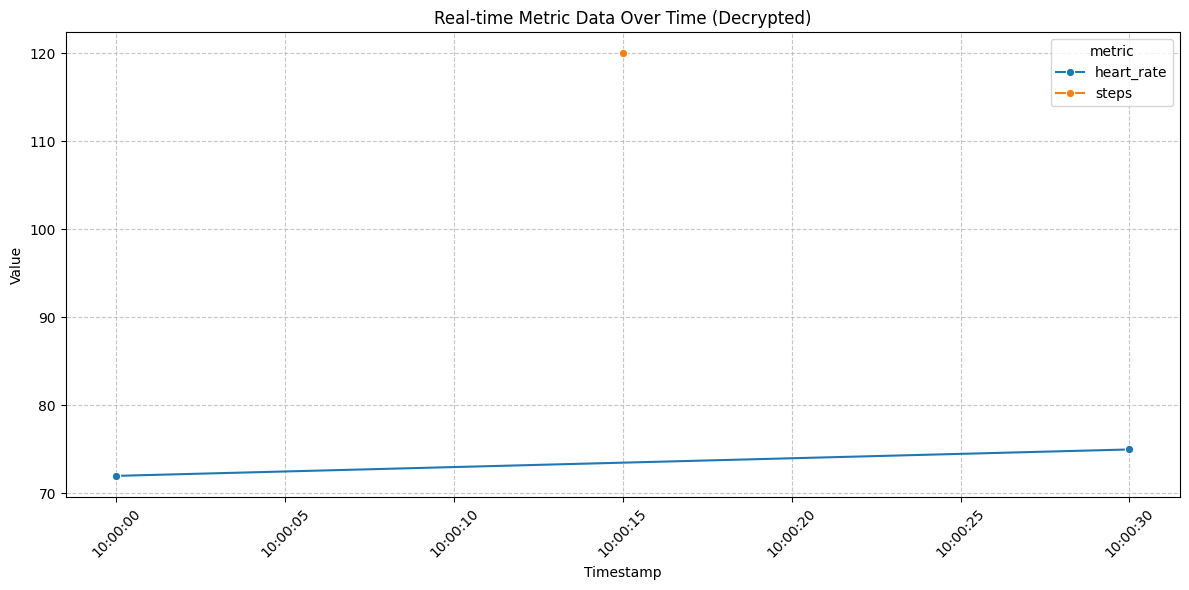

In [ ]:
# Plotting the metrics over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_metrics, x='timestamp', y='value', hue='metric', marker='o')

plt.title('Real-time Metric Data Over Time (Decrypted)')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print(mock_database)

[b'gAAAAABpxNkXin4rJ4mf83J_RTAIj9joDoeAnp8lMVkkrV86OZlivPS_KlnmbJVgoXd96aayeKbVzTVkxi2-JdqIyk8Z8K3aPwFGHd1Qu07NUPMtxbUWxS4X-B1PCCF_rpbaH-Owf-M1AeEHM66MQIdUUhJSiAbEE4xBrI7e6MPnL-W9BBJ_lt6kFvxNRGTRcI1qoq5wiCZ2m9Vps3W3cfv8-F7fJkeJ9A==', b'gAAAAABpxNkXiscfERTcJvcv2Co1vO1uqpCHW8csiqDdMNwG3FO878vxGGF8u32H3E2Vh9HcXBaUKajaD1oSLRcXLc8DwklBxL8iiVoBG4pYAhXI_HzuDNwPQ_NcJNtOKN7S6bIn0whBHuhQIu2gRFgoTIVHgQf0uLatkh_C6Woa8dwVKc4t12b7Rxx9XANQri7tmHByuVCw', b'gAAAAABpxNkXEDPQuHT8jRjmbSRM9pbU39Ri23RuSV7aUdhdwHoANBslgiBoaZOLAuYMu9TIwBuY9jwk8BWo6I16VtVUCKMsXoIPjFz6K2FalJyuG1_OUfk7phIZ3-JffbKXBNRhDWw-Zwapw2eOQakayGWNwY3oslyRgTjUdypCSfk_u7yRgUf0HHVDFJC-lNr2Pr3YEU5gpDiHHNYXDPDcb-7-lIucQA==']


In [ ]:
print(f"Number of items in mock_database: {len(mock_database)}")

Number of items in mock_database: 3


In [ ]:
print('Original Heart Rate Data 1:', heart_rate_data_1)
print('Original Steps Data 1:', steps_data_1)
print('Original Heart Rate Data 2:', heart_rate_data_2)

Original Heart Rate Data 1: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:00Z', 'metric': 'heart_rate', 'value': 72}
Original Steps Data 1: {'user_id': 'user_456', 'timestamp': '2023-10-27T10:00:15Z', 'metric': 'steps', 'value': 120}
Original Heart Rate Data 2: {'user_id': 'user_123', 'timestamp': '2023-10-27T10:00:30Z', 'metric': 'heart_rate', 'value': 75}


In [ ]:
print(mock_database)

[b'gAAAAABpxNkXin4rJ4mf83J_RTAIj9joDoeAnp8lMVkkrV86OZlivPS_KlnmbJVgoXd96aayeKbVzTVkxi2-JdqIyk8Z8K3aPwFGHd1Qu07NUPMtxbUWxS4X-B1PCCF_rpbaH-Owf-M1AeEHM66MQIdUUhJSiAbEE4xBrI7e6MPnL-W9BBJ_lt6kFvxNRGTRcI1qoq5wiCZ2m9Vps3W3cfv8-F7fJkeJ9A==', b'gAAAAABpxNkXiscfERTcJvcv2Co1vO1uqpCHW8csiqDdMNwG3FO878vxGGF8u32H3E2Vh9HcXBaUKajaD1oSLRcXLc8DwklBxL8iiVoBG4pYAhXI_HzuDNwPQ_NcJNtOKN7S6bIn0whBHuhQIu2gRFgoTIVHgQf0uLatkh_C6Woa8dwVKc4t12b7Rxx9XANQri7tmHByuVCw', b'gAAAAABpxNkXEDPQuHT8jRjmbSRM9pbU39Ri23RuSV7aUdhdwHoANBslgiBoaZOLAuYMu9TIwBuY9jwk8BWo6I16VtVUCKMsXoIPjFz6K2FalJyuG1_OUfk7phIZ3-JffbKXBNRhDWw-Zwapw2eOQakayGWNwY3oslyRgTjUdypCSfk_u7yRgUf0HHVDFJC-lNr2Pr3YEU5gpDiHHNYXDPDcb-7-lIucQA==']


In [ ]:
# import websockets
# import asyncio

# # (Key and fernet object would be initialized globally or passed securely)
# # key = Fernet.generate_key()
# # fernet = Fernet(key)

# async def websocket_handler(websocket, path):
#     async for message in websocket:
#         print(f"Received message from client: {message}")
#         try:
#             # Assume message is a JSON string from the client
#             raw_data = json.loads(message)

#             # Encrypt and store the payload
#             data_bytes = json.dumps(raw_data).encode('utf-8')
#             encrypted_payload = fernet.encrypt(data_bytes)

#             # In a real application, save to a persistent database
#             mock_database.append(encrypted_payload) # Using our mock_database for demonstration
#             print(f"Successfully encrypted and stored data for user: {raw_data.get('user_id')}")

#             await websocket.send(json.dumps({"status": "success", "message": "Data received and stored."}))
#         except json.JSONDecodeError:
#             print("Received non-JSON message.")
#             await websocket.send(json.dumps({"status": "error", "message": "Invalid JSON format."}))
#         except Exception as e:
#             print(f"Error processing message: {e}")
#             await websocket.send(json.dumps({"status": "error", "message": str(e)}))

# # To run this, you would typically use:
# # start_server = websockets.serve(websocket_handler, "localhost", 8765)
# # asyncio.get_event_loop().run_until_complete(start_server)
# # asyncio.get_event_loop().run_forever()
